In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d

In [2]:
def downsample(input_data_df, original_sampling_rate_hz, target_sampling_rate_hz):
    """Downsample the data in the input_data_df from the original sampling rate to a given target sampling rate."""
    data_array = input_data_df.values
    len_data = data_array.shape[0]
    current_x = np.linspace(0, len_data, len_data)
    data_array_downsampled = interp1d(current_x, data_array, axis=0)(
        np.linspace(0, len_data, int(len_data * target_sampling_rate_hz / original_sampling_rate_hz))
    )

    output_data_df = pd.DataFrame(data_array_downsampled, columns=input_data_df.columns)

    return output_data_df

In [16]:
# low_pass_filter_Data
def low_pass_filter(sig, fs, f_cut, order):
    """
    applies zero-lag butterworth filter to a signal
    :param sig: signal to be filtered - np.array
    :param fs: sampling frequency of sig - integer
    :param f_cut: cut-off frequency (low-pass) - integer
    :param order: order of filter - integer
    :return sig_filt: filtered signal - np array
    """
    # design filter
    nf = f_cut/(fs/2)
    b, a = butter(order, nf, btype='low')

    # apply filter
    sig_filt = filtfilt(b, a, sig.values, axis=0, padtype='odd', padlen=3*(max(len(b), len(a))-1))
    return sig_filt

In [22]:
def segment_steps(force_df, fs):
    f_vert = pd.DataFrame(-force_df["Fz"])
     # get highly smoothed signal for peak detection
    highly_smoothed_sig = low_pass_filter(f_vert, fs, 5, 4)

    # grab all smooth peaks above 500 Newtons
    peaks, _ = find_peaks(highly_smoothed_sig.squeeze(), height=500)
    # remove first and last peaks to avoid partial GRFs
    # peaks = np.delete(peaks, [0, -1])

    # squeeze to np array for further processing
    slightly_smoothed_sig = f_vert.values.squeeze()

    # extract HS (search from peak to the left while GRF > 20)
    HS_list = []
    # extract TO (search from peak to the right while GRF > 20)
    TO_list = []

    for peak in peaks:
        peak_hs_copy = peak
        while (peak_hs_copy > 0) & (slightly_smoothed_sig[peak_hs_copy] > 20):
            peak_hs_copy = peak_hs_copy - 1
        HS_list.append(peak_hs_copy + 1)  # go one back

        peak_to_copy = peak
        while (peak_to_copy < len(slightly_smoothed_sig)) & (slightly_smoothed_sig[peak_to_copy] > 20):
            peak_to_copy = peak_to_copy + 1
        TO_list.append(peak_to_copy - 1)  # go on back

    HS_list = list(set(HS_list))  # removes possible duplicates
    HS_list.sort()

    TO_list = list(set(TO_list))  # removes possible duplicates
    TO_list.sort()

    # make sure to start with HS and end with TO
    if HS_list[0] > TO_list[0]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    elif HS_list[-1] > TO_list[-1]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    try:
        len(TO_list) == len(HS_list)
    except:
        print("different number of HS and TO detected, something is wrong here..")
    
    IC = np.array(HS_list)
    TO = np.array(TO_list)
    return IC, TO

In [131]:
def get_detection_windows(foot_imu_df, sampling_rate):
    """
    calculates the search windows for  IC and TO search
    :param foot_imu_df: DataFrame with Foot IMU for one Side
    :param sampling_rate: Sampling Rate - integer
    :return window_dict: dict with Lists of interval boundries for IC and TO search
    """

    # get midswing indices
    midswing = get_midswing(foot_imu_df.iloc[:,4], sampling_rate)

    # filter all Data at 30 Hz
    foot_df_filt = pd.DataFrame(low_pass_filter(foot_imu_df, sampling_rate, 30, 2), columns=foot_imu_df.columns)

    # get interval boundries based on Angular Velocity Signal
    ang_norm = np.linalg.norm(foot_df_filt.iloc[:,3:6], axis = 1)

    # init empty lists
    TO_end = []
    IC_start = []
    mid = []

    # for each step (between 2 midswing events):
    # find 3 peaks (1st = midstance, 2nd = TO upper boundry, 3rd = IC lower boundry (of the next step))
    for i in range(len(midswing) - 1):
        peaks, _ = find_peaks(-ang_norm[midswing[i]:midswing[i + 1]], prominence=250) # <-- 150 just a guess
        if len(peaks)==3:
            mid.append(peaks[0] + midswing[i])
            TO_end.append(peaks[1] + midswing[i])
            IC_start.append(peaks[2] + midswing[i])

    # clip first element of mid and TO_end & last element of IC_start to allign order
    mid = mid[1:]
    TO_end = TO_end[1:]
    IC_start = IC_start[:-1]

    window_dict = {'lower_IC': IC_start,
                   'upper_IC': mid,
                   'lower_TO': mid,
                   'upper_TO': TO_end}
    return window_dict

In [5]:
def get_midswing(gyr_y_series, fs):
    """
    finds peaks in Angular Velocity around Y Axis of Foot IMU with distance of at least 0.5 s for the same side
    :param gyr_y_series: array or pd.Series with gyr_y signal
    :param fs: integer with sampling rate
    :return int array with mid_swing indices:
    """
    gyr_y_filt = low_pass_filter(gyr_y_series, 2000, 90, 2)
    mid_swing, _ = find_peaks(gyr_y_filt, distance = fs * 60 / 100)
    return mid_swing

In [6]:
def k1(slice_df):
    """
    global minimum of angular velocity around y
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC as int
    """
    return int(slice_df.iloc[:,4].idxmin())

def k3(slice_df):
    """
    first minimum of angular velocity around y < 100°/s
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    # find first peak lower than 100
    peaks, _ = find_peaks(-slice_df.iloc[:,4], height = -100)
    try:
        IC = int(peaks[0] + slice_df.index[0])
    except:
        print('could not find IC in k3')
        IC = None
    return IC

def k7(slice_df):
    """
    global maximum of angular velocity norm
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return int(np.argmax(np.linalg.norm(slice_df.iloc[:,3:6], axis = 1)) + slice_df.index[0])

def k8(slice_df):
    """
    global maximum of vertical acceleration
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return int(slice_df.iloc[:,2].idxmax())

def k9(slice_df):
    """
    global maximum of acceleration norm
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return int(np.argmax(np.linalg.norm(slice_df.iloc[:,:3], axis = 1)) + slice_df.index[0])

def t1(slice_df):
    """
    global minimum of angular velocity around y
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return k1(slice_df)

def t4(slice_df):
    """
    global maximum of angular velocity norm
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return k7(slice_df)

def t8(slice_df):
    """
        global maximum of angular velocity norm
        :param slice_df: DataFrame slice of current interval for IC detection
        :return IC index as int
        """
    return k9(slice_df)

In [7]:
# import data
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\PI_FP_IMU\\RUN_03.csv', sep = ',', header = [3], low_memory = False)
ff = df.iloc[df[df['Frame']=='Frame'].index[0]+2:, :]
ff.columns = df.iloc[df[df['Frame']=='Frame'].index[0],:].values.tolist()
force_df = ff[['Frame', 'Sub Frame', 'Fx','Fy','Fz','Mx','My','Mz','Cx','Cy','Cz']].astype('float')
imu_df = df.iloc[1:df[df['Frame']=='Devices'].index[0], :].astype('float')

In [395]:
# downsample IMU data to 1000 Hz to match force plate
imu_down = imu_df[::2]

In [396]:
# find true peaks force plate
ref = pd.DataFrame(segment_steps(force_df, 1000), index=['IC_true', 'TO_true']).T
ref

,IC_true,TO_true
0,1526,1728
1,1746,2025
2,2122,2365
3,2548,2770
4,2931,3155
...,...,...
151,58105,58345
152,58464,58712
153,58846,59085
154,59213,59456


In [397]:
#  find IMU events

# separate sides
left_foot = imu_down[imu_down.columns[imu_down.columns.str.contains(pat = 'IMU1_')]]
right_foot = imu_down[imu_down.columns[imu_down.columns.str.contains(pat = 'IMU2_')]]
# detection windows
windows_right = get_detection_windows(right_foot, 1000)
windows_left = get_detection_windows(left_foot, 1000)

# left side:
events_left = pd.DataFrame(data=None)
for i in range(len(windows_left['lower_IC'])):
    # IC Detection: slice current detection window
    ic_window = left_foot.loc[windows_left['lower_IC'][i]:windows_left['upper_IC'][i]]
    # k1 global min of angular velocity around Y
    events_left.loc[i, 'IC_1']=k1(ic_window)
    # k3 first min of angular velocity around Y < 100°/s
    events_left.loc[i, 'IC_3'] = k3(ic_window)
    # k7 global max of angular velocity norm
    events_left.loc[i, 'IC_7'] = k7(ic_window)
    # k8 global max of vertical acceleration (Z)
    events_left.loc[i, 'IC_8'] = k8(ic_window)
    # k9 global max of acceleration norm
    events_left.loc[i, 'IC_9'] = k9(ic_window)
    
    # TO Detection8 window
    to_window = left_foot.loc[windows_left['lower_TO'][i]:windows_left['upper_TO'][i]]
    # t1 global min of angular velocity around Y
    events_left.loc[i, 'TO_1'] = t1(to_window)
    # t4 global max of angular velocity norm
    events_left.loc[i, 'TO_4'] = t4(to_window)
    # t8 global max of acceleration norm
    events_left.loc[i, 'TO_8'] = t8(to_window)

# right side:
events_right = pd.DataFrame(data=None)
for i in range(len(windows_right['lower_IC'])):
    # IC Detection: slice current detection window
    ic_window = right_foot.loc[windows_right['lower_IC'][i]:windows_right['upper_IC'][i]]
    # k1 global min of angular velocity around Y
    events_right.loc[i, 'IC_1']=k1(ic_window)
    # k3 first min of angular velocity around Y < 100°/s
    events_right.loc[i, 'IC_3'] = k3(ic_window)
    # k7 global max of angular velocity norm
    events_right.loc[i, 'IC_7'] = k7(ic_window)
    # k8 global max of vertical acceleration (Z)
    events_right.loc[i, 'IC_8'] = k8(ic_window)
    # k9 global max of acceleration norm
    events_right.loc[i, 'IC_9'] = k9(ic_window)

    # TO Detection8 window
    to_window = right_foot.loc[windows_right['lower_TO'][i]:windows_right['upper_TO'][i]]
    # t1 global min of angular velocity around Y
    events_right.loc[i, 'TO_1'] = t1(to_window)
    # t4 global max of angular velocity norm
    events_right.loc[i, 'TO_4'] = t4(to_window)
    # t8 global max of acceleration norm
    events_right.loc[i, 'TO_8'] = t8(to_window)

could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find I

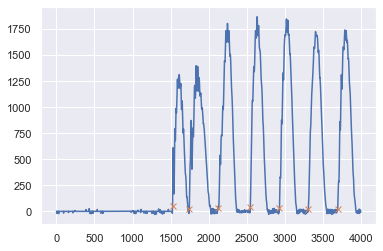

In [398]:
t = 4000
plt.plot(-force_df['Fz'].values[:t])
plt.plot(ref['IC_true'][ref['IC_true']<t], -force_df['Fz'].values[:t][ref['IC_true'][ref['IC_true']<t]],'x')

In [399]:
print(len(events_right)+len(events_left))
print(len(ref))

152
156


In [400]:
print(ref['IC_true'].values)
print(events_right['IC_1'].astype('int').values)

[ 1526  1746  2122  2548  2931  3310  3696  4056  4441  4811  5190  5566
  5957  6334  6715  7083  7469  7854  8234  8617  9004  9382  9760 10150
 10523 10899 11274 11642 12026 12404 12768 13153 13536 13911 14290 14665
 15036 15417 15795 16175 16549 16915 17294 17674 18047 18417 18796 19181
 19561 19922 20304 20674 21043 21418 21802 22183 22559 22929 23303 23682
 24064 24438 24818 25198 25556 25933 26308 26687 27069 27442 27817 28195
 28560 28944 29316 29691 30073 30437 30819 31186 31569 31934 32315 32696
 33062 33437 33808 34176 34553 34918 35293 35669 36044 36423 36796 37161
 37546 37910 38292 38673 39040 39412 39778 40154 40531 40910 41288 41657
 42028 42396 42769 43133 43520 43880 44267 44639 45017 45381 45764 46138
 46520 46879 47256 47626 48004 48370 48743 49111 49486 49850 50237 50607
 50987 51362 51728 52111 52487 52842 53214 53611 53985 54346 54726 55109
 55487 55864 56228 56603 56976 57341 57725 58105 58464 58846 59213 59580]
[ 2789  3471  4329  4859  5635  6379  7189  7895  

In [401]:
ref['IC_true'].values[2:-2][::2]

array([ 2122,  2931,  3696,  4441,  5190,  5957,  6715,  7469,  8234,
        9004,  9760, 10523, 11274, 12026, 12768, 13536, 14290, 15036,
       15795, 16549, 17294, 18047, 18796, 19561, 20304, 21043, 21802,
       22559, 23303, 24064, 24818, 25556, 26308, 27069, 27817, 28560,
       29316, 30073, 30819, 31569, 32315, 33062, 33808, 34553, 35293,
       36044, 36796, 37546, 38292, 39040, 39778, 40531, 41288, 42028,
       42769, 43520, 44267, 45017, 45764, 46520, 47256, 48004, 48743,
       49486, 50237, 50987, 51728, 52487, 53214, 53985, 54726, 55487,
       56228, 56976, 57725, 58464], dtype=int64)

In [402]:
events_left['IC_1'].astype('int').values

array([ 2171,  3023,  3765,  4483,  5313,  6007,  6937,  7511,  8435,
        9059,  9953, 10563, 11445, 12073, 12957, 13577, 14489, 15435,
       15993, 16583, 17521, 18083, 19049, 19621, 20555, 21125, 22057,
       22651, 23561, 24101, 25071, 25647, 26557, 27117, 28071, 28651,
       29581, 30117, 31075, 31619, 32577, 33109, 34065, 34609, 35543,
       36099, 37059, 37617, 38561, 39109, 40043, 40613, 41547, 42085,
       43027, 43603, 44525, 45121, 46025, 46613, 47529, 48125, 49139,
       49637, 50507, 51121, 51985, 52619, 53471, 54145, 54973, 55637,
       56483, 57141, 57985, 58645])

In [403]:
ref['IC_true'].values[3:-1][::2]

array([ 2548,  3310,  4056,  4811,  5566,  6334,  7083,  7854,  8617,
        9382, 10150, 10899, 11642, 12404, 13153, 13911, 14665, 15417,
       16175, 16915, 17674, 18417, 19181, 19922, 20674, 21418, 22183,
       22929, 23682, 24438, 25198, 25933, 26687, 27442, 28195, 28944,
       29691, 30437, 31186, 31934, 32696, 33437, 34176, 34918, 35669,
       36423, 37161, 37910, 38673, 39412, 40154, 40910, 41657, 42396,
       43133, 43880, 44639, 45381, 46138, 46879, 47626, 48370, 49111,
       49850, 50607, 51362, 52111, 52842, 53611, 54346, 55109, 55864,
       56603, 57341, 58105, 58846], dtype=int64)

In [404]:
events_right['IC_1'].astype('int').values

array([ 2789,  3471,  4329,  4859,  5635,  6379,  7189,  7895,  8661,
        9427, 10213, 10943, 11723, 12451, 13229, 13957, 15073, 15465,
       16233, 16961, 17745, 18521, 19277, 20005, 20803, 21525, 22323,
       23057, 23799, 24487, 25341, 25997, 26829, 27585, 28315, 29035,
       29841, 30483, 31409, 31979, 32829, 33593, 34363, 35111, 35847,
       36547, 37351, 37957, 38871, 39565, 40375, 41041, 41867, 42445,
       43367, 43939, 44893, 45577, 46395, 47061, 47893, 48643, 49383,
       50107, 50657, 51463, 52369, 52949, 53653, 54445, 55163, 55951,
       56655, 57613, 58143, 58961])

In [405]:
ic_ref_left = ref['IC_true'].values[2:-2][::2]
ic_ref_right = ref['IC_true'].values[3:-1][::2]

<AxesSubplot:>

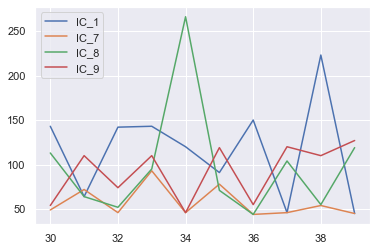

In [406]:
dif_right = pd.DataFrame(columns=['IC_1', 'IC_7', 'IC_8', 'IC_9'])
for col in ['IC_1', 'IC_7', 'IC_8', 'IC_9']:
    dif_right[col]=events_right[col].astype('int')-ic_ref_right
dif_right[30:40].plot()  

<AxesSubplot:>

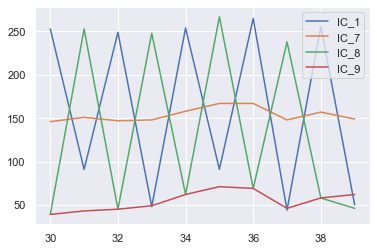

In [407]:
dif_left = pd.DataFrame(columns=['IC_1', 'IC_7', 'IC_8', 'IC_9'])
for col in ['IC_1', 'IC_7', 'IC_8', 'IC_9']:
    dif_left[col]=events_left[col].astype('int')-ic_ref_left
dif_left[30:40].plot()   

In [408]:
dif_left.idxmin()

IC_1    19
IC_7    52
IC_8    20
IC_9    20
dtype: int64

In [409]:
# same for TO
to_ref_right = ref['TO_true'].values[4::2]

In [410]:
events_right['TO_1'].astype('int').values

array([ 2835,  3583,  4611,  5095,  6161,  6629,  7707,  8119,  9219,
        9635, 10703, 11165, 12325, 12675, 13755, 14189, 15267, 15707,
       16785, 17239, 18361, 18765, 19845, 20299, 21371, 21797, 22875,
       23295, 24367, 24815, 25865, 26319, 27383, 27831, 28885, 29337,
       30383, 30849, 31887, 32355, 33381, 33831, 34873, 35343, 36365,
       36841, 37869, 38369, 39351, 39671, 40845, 41341, 42343, 42841,
       43835, 44169, 45333, 45865, 46837, 47149, 48317, 48653, 49803,
       50135, 51303, 51661, 52801, 53127, 54297, 54623, 55801, 56129,
       57293, 57631, 58783, 59151])

In [411]:
to_ref_left=ref['TO_true'].values[3::2][:-1]

<AxesSubplot:>

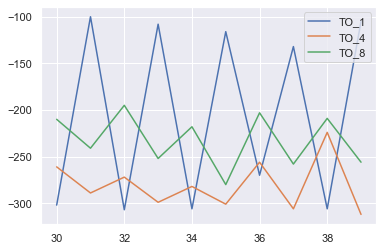

In [412]:
diff_left = pd.DataFrame(columns=['TO_1', 'TO_4', 'TO_8'])
for col in ['TO_1', 'TO_4', 'TO_8']:
    diff_left[col]=events_left[col].astype('int')-to_ref_left
diff_left[30:40].plot() 

In [413]:
dif_left.idxmin()

IC_1    19
IC_7    52
IC_8    20
IC_9    20
dtype: int64

<AxesSubplot:>

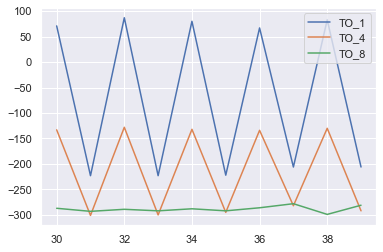

In [414]:
diff_right = pd.DataFrame(columns=['TO_1', 'TO_4', 'TO_8'])
for col in ['TO_1', 'TO_4', 'TO_8']:
    diff_right[col]=events_right[col].astype('int')-to_ref_right
diff_right[30:40].plot()   

In [415]:
dif_right.idxmin()

IC_1    74
IC_7     7
IC_8     0
IC_9     0
dtype: int64

In [416]:
import seaborn as sns
sns.set_theme()
# IC Detection: slice current detection window
    ic_window = left_foot.loc[windows_left['lower_IC'][i]:windows_left['upper_IC'][i]]
    # k1 global min of angular velocity around Y
    events_left.loc[i, 'IC_1']=k1(ic_window)
    # k3 first min of angular velocity around Y < 100°/s
    events_left.loc[i, 'IC_3'] = k3(ic_window)
    # k7 global max of angular velocity norm
    events_left.loc[i, 'IC_7'] = k7(ic_window)
    # k8 global max of vertical acceleration (Z)
    events_left.loc[i, 'IC_8'] = k8(ic_window)
    # k9 global max of acceleration norm

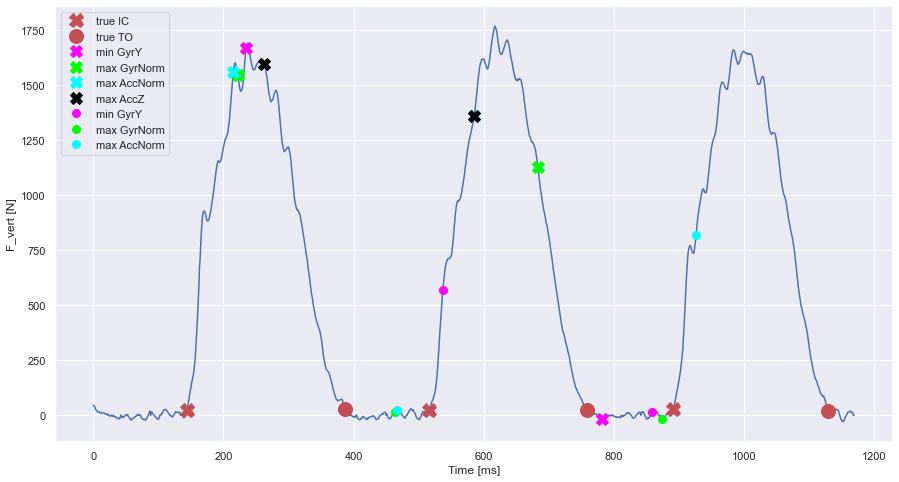

In [476]:
# example

fig = plt.figure(figsize=[15,8])
x= np.linspace(0,1,1000)
plt.plot(-force_df['Fz'].values[28800:29970])
#plt.plot(np.linalg.norm(left_foot.iloc[:,:3], axis=1)[28800:29970])
plt.plot(true_ic, -force_df['Fz'].values[28800:29970][true_ic], 'X', color='r', markersize=14, label='true IC')
plt.plot(true_to, -force_df['Fz'].values[28800:29970][true_to], 'o', color='r', markersize=14, label='true TO')
plt.plot(IC1, -force_df['Fz'].values[28800:29970][IC1], 'X', color='magenta', markersize=12, label='min GyrY')
plt.plot(IC7, -force_df['Fz'].values[28800:29970][IC7], 'X', color='lime', markersize=12, label='max GyrNorm')
plt.plot(IC8, -force_df['Fz'].values[28800:29970][IC8], 'X', color='cyan', markersize=12, label='max AccNorm')
plt.plot(IC9, -force_df['Fz'].values[28800:29970][IC9], 'X', color='black', markersize=12, label='max AccZ')
plt.plot(TO1, -force_df['Fz'].values[28800:29970][TO1], 'o', color='magenta', markersize=8, label='min GyrY')
plt.plot(TO4, -force_df['Fz'].values[28800:29970][TO4], 'o', color='lime', markersize=8, label='max GyrNorm')
plt.plot(TO8, -force_df['Fz'].values[28800:29970][TO8], 'o', color='cyan', markersize=8, label='max AccNorm')
plt.xlabel('Time [ms]')
plt.ylabel('F_vert [N]')
plt.legend()

In [474]:
true_ic = ref['IC_true'][73:76].values-28800
true_to = ref['TO_true'][73:76].values-28800
IC1 = np.array([events_right['IC_1'].astype('int').values[35], events_left['IC_1'].astype('int').values[36]])-28800
IC7 = np.array([events_right['IC_7'].astype('int').values[35], events_left['IC_7'].astype('int').values[36]])-28800
IC8 = np.array([events_right['IC_8'].astype('int').values[35], events_left['IC_8'].astype('int').values[36]])-28800
IC9 = np.array([events_right['IC_9'].astype('int').values[35], events_left['IC_9'].astype('int').values[36]])-28800
TO1 = np.array([events_right['TO_1'].astype('int').values[35], events_left['TO_1'].astype('int').values[36]])-28800
TO4 = np.array([events_right['TO_4'].astype('int').values[35], events_left['TO_4'].astype('int').values[36]])-28800
TO8 = np.array([events_right['TO_8'].astype('int').values[35], events_left['TO_8'].astype('int').values[36]])-28800

In [392]:
events_right['TO_1'].astype('int').values[35]

29575

In [391]:
events_left['TO_8'].astype('int').values[35]

29214

In [322]:
events_right['IC_1'].astype('int').values[35]

28992

In [323]:
events_left['IC_1'].astype('int').values[36]

29383

In [331]:
ref['IC_true'][74]

29316

In [449]:
a = pd.DataFrame([events_right['TO_1']-events_right['IC_1'], events_right['TO_4']-events_right['IC_7'], events_right['TO_8']-events_right['IC_9']], index=['GyrY_min', 'GyrNorm_max', 'AccNorm_max']).T
b = pd.DataFrame([events_left['TO_1']-events_left['IC_1'], events_left['TO_4']-events_left['IC_7'], events_left['TO_8']-events_left['IC_9']], index=['GyrY_min', 'GyrNorm_max', 'AccNorm_max']).T

c = pd.concat([a,b]).reset_index()
c['Force_Plate']=ref['TO_true']-ref['IC_true']

<AxesSubplot:>

<Figure size 1080x576 with 0 Axes>

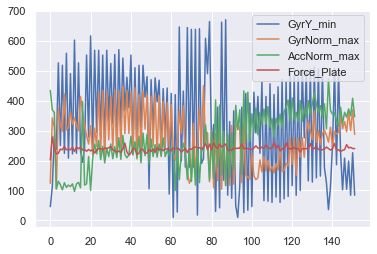

In [455]:
fig = plt.figure(figsize=[15,8])
c.iloc[:,1:].plot()